In [1]:
import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages io.delta:delta-spark_2.12:3.2.0 pyspark-shell'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.driver.memory", "2g") \
    .master("local[2]") \
    .getOrCreate()

print("Spark hazır:", spark.version)

Spark hazır: 3.5.0


In [2]:
from pyspark.sql.functions import col, avg, count, year, hour, from_unixtime

ratings = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/ratings.csv", 
                         header=True, inferSchema=True).limit(1000000)

movies = spark.read.csv("/home/jovyan/data/ml-25m/ml-25m/movies.csv", 
                        header=True, inferSchema=True)

silver = ratings.dropna().dropDuplicates() \
    .join(movies, on="movieId", how="left") \
    .withColumn("rating_date", from_unixtime(col("timestamp")).cast("timestamp"))

movie_stats = silver.groupBy("movieId").agg(
    avg("rating").alias("movie_avg_rating"),
    count("rating").alias("movie_rating_count")
)

user_stats = silver.groupBy("userId").agg(
    avg("rating").alias("user_avg_rating"),
    count("rating").alias("user_rating_count")
)

gold = silver \
    .join(movie_stats, on="movieId", how="left") \
    .join(user_stats, on="userId", how="left") \
    .withColumn("rating_year", year(col("rating_date"))) \
    .withColumn("rating_hour", hour(col("rating_date")))

print("Gold hazır, satır:", gold.count())

Gold hazır, satır: 1000000


In [3]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor, GeneralizedLinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
import mlflow
import mlflow.spark

feature_cols = ["movie_avg_rating", "movie_rating_count", "user_avg_rating", "user_rating_count", "rating_year", "rating_hour"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data = assembler.transform(gold.dropna()).select("features", "rating")

train, test = data.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count(), "Test:", test.count())

Train: 800368 Test: 199632


In [4]:
mlflow.set_experiment("movielens_rating_prediction")

modeller = {
    "Linear Regression": LinearRegression(featuresCol="features", labelCol="rating"),
    "Decision Tree": DecisionTreeRegressor(featuresCol="features", labelCol="rating"),
    "Random Forest": RandomForestRegressor(featuresCol="features", labelCol="rating"),
    "GBT": GBTRegressor(featuresCol="features", labelCol="rating"),
    "GLR": GeneralizedLinearRegression(featuresCol="features", labelCol="rating", family="gaussian")
}

evaluator_rmse = RegressionEvaluator(labelCol="rating", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="rating", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="rating", predictionCol="prediction", metricName="r2")

sonuclar = {}

for isim, model in modeller.items():
    print(f"{isim} eğitiliyor...")
    with mlflow.start_run(run_name=isim):
        fitted = model.fit(train)
        preds = fitted.transform(test)
        
        rmse = evaluator_rmse.evaluate(preds)
        mae = evaluator_mae.evaluate(preds)
        r2 = evaluator_r2.evaluate(preds)
        
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        
        sonuclar[isim] = {"rmse": rmse, "mae": mae, "r2": r2}
        print(f"  RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

print("\nTüm modeller tamamlandı!")

2026/05/12 12:47:54 INFO mlflow.tracking.fluent: Experiment with name 'movielens_rating_prediction' does not exist. Creating a new experiment.


Linear Regression eğitiliyor...
  RMSE: 0.8538, MAE: 0.6538, R2: 0.3492
Decision Tree eğitiliyor...
  RMSE: 0.8676, MAE: 0.6651, R2: 0.3279
Random Forest eğitiliyor...
  RMSE: 0.8797, MAE: 0.6774, R2: 0.3090
GBT eğitiliyor...
  RMSE: 0.8549, MAE: 0.6543, R2: 0.3475
GLR eğitiliyor...
  RMSE: 0.8538, MAE: 0.6538, R2: 0.3492

Tüm modeller tamamlandı!


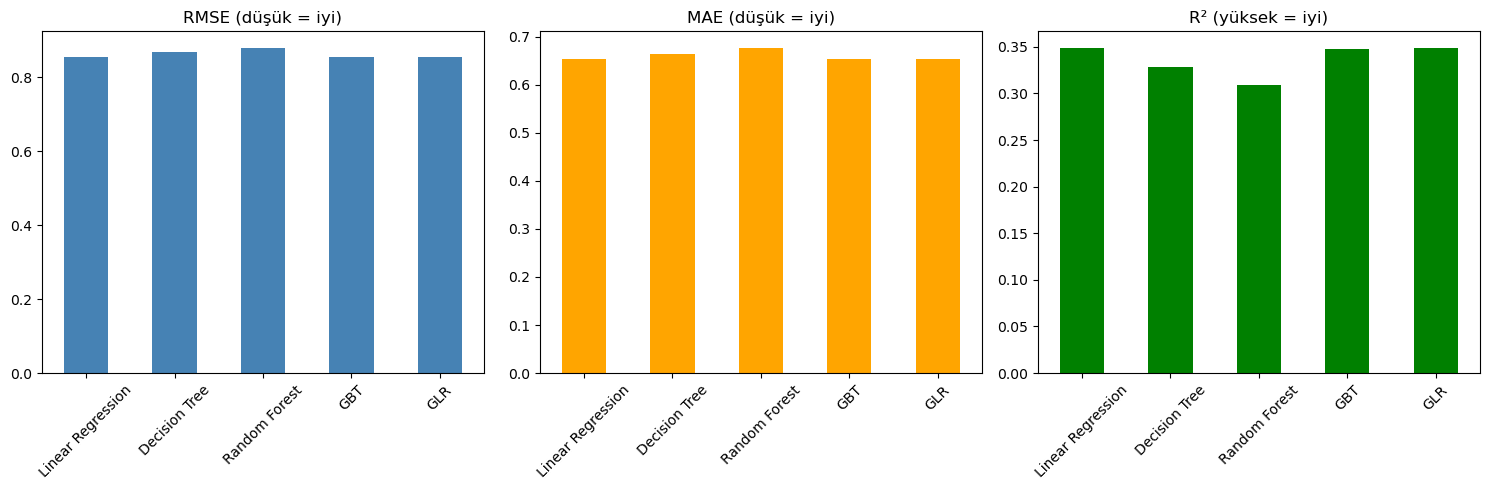

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(sonuclar).T

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df["rmse"].plot(kind="bar", ax=axes[0], color="steelblue", title="RMSE (düşük = iyi)")
df["mae"].plot(kind="bar", ax=axes[1], color="orange", title="MAE (düşük = iyi)")
df["r2"].plot(kind="bar", ax=axes[2], color="green", title="R² (yüksek = iyi)")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

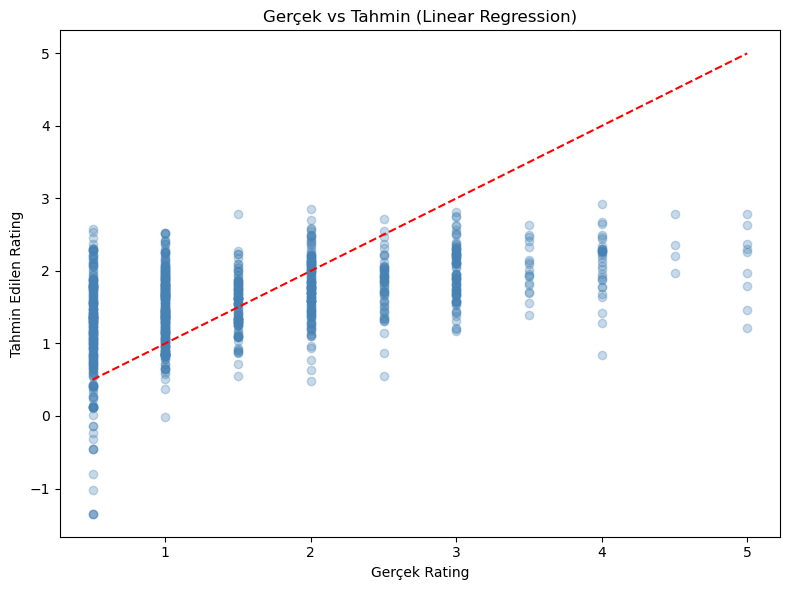

In [6]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="rating")
lr_model = lr.fit(train)
preds = lr_model.transform(test)

preds_pd = preds.select("rating", "prediction").limit(1000).toPandas()

plt.figure(figsize=(8,6))
plt.scatter(preds_pd["rating"], preds_pd["prediction"], alpha=0.3, color="steelblue")
plt.plot([0.5, 5], [0.5, 5], color="red", linestyle="--")
plt.title("Gerçek vs Tahmin (Linear Regression)")
plt.xlabel("Gerçek Rating")
plt.ylabel("Tahmin Edilen Rating")
plt.tight_layout()
plt.show()

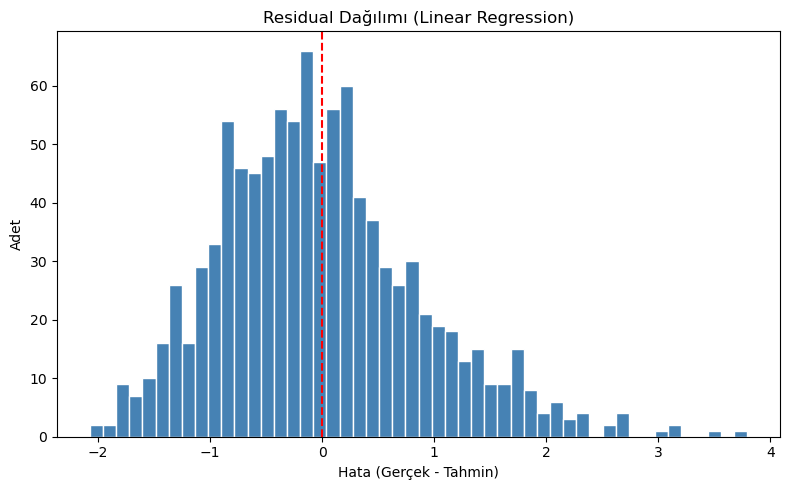

In [7]:
preds_pd["residual"] = preds_pd["rating"] - preds_pd["prediction"]

plt.figure(figsize=(8,5))
plt.hist(preds_pd["residual"], bins=50, color="steelblue", edgecolor="white")
plt.title("Residual Dağılımı (Linear Regression)")
plt.xlabel("Hata (Gerçek - Tahmin)")
plt.ylabel("Adet")
plt.axvline(x=0, color="red", linestyle="--")
plt.tight_layout()
plt.show()